# Mundial26 — Phase 3: The Dixon–Coles Goals Model

This is the heart of the project. Instead of predicting the outcome directly (which, in
Phase 2, meant the model basically never predicted draws), we model **how many goals each
team scores**, then derive win / draw / loss probabilities from the full distribution of
scorelines.

### The idea in plain terms
Every team gets two numbers learned from data:
- an **attack** strength (how many goals they tend to score)
- a **defense** strength (how many they tend to concede)

Plus one shared **home-advantage** term. For a given match we compute each team's expected
goals, treat goals as a Poisson process, and read off the probability of every scoreline
(0-0, 1-0, 2-1, …). Summing those gives clean win/draw/loss probabilities — and draws come
out *naturally*.

### Why "Dixon–Coles" and not plain Poisson
Maher (1982) introduced the attack/defense Poisson idea. Dixon & Coles (1997) added a small
correction (a parameter ρ) for low-scoring games, because plain Poisson under-predicts
exactly the 0-0, 1-0, 0-1 and 1-1 results that football produces a lot of. We also weight
recent matches more heavily, since form decays over time. Using this is a signal you know
the actual football-analytics literature.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load data
Same raw file as before. We sort by date and build the outcome label.

In [2]:
df = pd.read_csv("../data/raw/results.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

def outcome(r):
    if r["home_score"] > r["away_score"]: return "home_win"
    if r["home_score"] < r["away_score"]: return "away_win"
    return "draw"
df["result"] = df.apply(outcome, axis=1)
print("Total matches:", len(df))

Total matches: 49477


## 3. Train / test split

To compare fairly against Phase 2, we use the **same split**: train on matches before 2018,
test on 2018 onward.

For fitting the Dixon–Coles model we use the most recent decade of training data
(2008–2017) with **time-decay weighting** — older matches still count, but less. We also
keep only teams with enough matches to estimate reliably.

In [3]:
CUTOFF = pd.Timestamp("2018-01-01")

train = df[df["date"] < CUTOFF].copy()
test  = df[df["date"] >= CUTOFF].copy()

# Recent decade for fitting strengths
fit_df = train[train["date"] >= "2008-01-01"].copy()

# Keep teams with >= 20 matches in the fitting window
counts = pd.concat([fit_df["home_team"], fit_df["away_team"]]).value_counts()
good_teams = set(counts[counts >= 20].index)
fit_df = fit_df[fit_df["home_team"].isin(good_teams) & fit_df["away_team"].isin(good_teams)].reset_index(drop=True)

teams = sorted(set(fit_df["home_team"]) | set(fit_df["away_team"]))
team_idx = {t: i for i, t in enumerate(teams)}
n = len(teams)
print(f"Fitting on {len(fit_df)} matches across {n} teams")

Fitting on 9198 matches across 216 teams


### Time-decay weights
A match's influence halves roughly every `half_life` days. We anchor the decay at the cutoff
date, so matches just before 2018 carry the most weight.

In [4]:
half_life = 365 * 2          # ~2 years
age_days = (CUTOFF - fit_df["date"]).dt.days.values
weights = 0.5 ** (age_days / half_life)

hi = fit_df["home_team"].map(team_idx).values
ai = fit_df["away_team"].map(team_idx).values
hg = fit_df["home_score"].values.astype(float)
ag = fit_df["away_score"].values.astype(float)
print("Most recent match weight:", round(weights.max(), 3), "| oldest:", round(weights.min(), 3))

Most recent match weight: 0.997 | oldest: 0.031


## 4. The Dixon–Coles likelihood

Parameters: an attack and a defense value per team, plus a global home term `gamma` and the
low-score correction `rho`. We find the values that make the observed scorelines most likely
(maximum likelihood = minimizing the negative log-likelihood). A tiny L2 penalty keeps the
strengths anchored and shrinks teams with little data toward average.

In [5]:
def neg_loglik(params, hi, ai, hg, ag, w, n, reg=1e-3):
    atk   = params[:n]
    dfn   = params[n:2*n]
    gamma = params[2*n]
    rho   = params[2*n + 1]

    log_lam = atk[hi] + dfn[ai] + gamma   # home expected goals (log)
    log_mu  = atk[ai] + dfn[hi]           # away expected goals (log)
    lam, mu = np.exp(log_lam), np.exp(log_mu)

    # Poisson log-pmf for each side
    ll = (hg*log_lam - lam - gammaln(hg+1)) + (ag*log_mu - mu - gammaln(ag+1))

    # Dixon-Coles low-score correction
    tau = np.ones_like(lam)
    m = (hg==0)&(ag==0); tau[m] = 1 - lam[m]*mu[m]*rho
    m = (hg==0)&(ag==1); tau[m] = 1 + lam[m]*rho
    m = (hg==1)&(ag==0); tau[m] = 1 + mu[m]*rho
    m = (hg==1)&(ag==1); tau[m] = 1 - rho
    tau = np.clip(tau, 1e-10, None)
    ll = ll + np.log(tau)

    return -np.sum(w*ll) + reg*(np.sum(atk**2) + np.sum(dfn**2))

### Fit the model
This runs an optimizer over all parameters. It typically takes around a minute or two.

In [6]:
x0 = np.concatenate([np.zeros(n), np.zeros(n), [0.3], [-0.05]])
bounds = [(-3, 3)]*n + [(-3, 3)]*n + [(-1.0, 2.0), (-0.2, 0.2)]

res = minimize(neg_loglik, x0, args=(hi, ai, hg, ag, weights, n),
               method="L-BFGS-B", bounds=bounds,
               options={"maxiter": 2000, "maxfun": 200000, "ftol": 1e-9, "gtol": 1e-6})

atk = res.x[:n]; dfn = res.x[n:2*n]; gamma = res.x[2*n]; rho = res.x[2*n+1]
print("Converged:", res.success)
print(f"Home advantage (gamma): {gamma:.3f}  ->  home teams score x{np.exp(gamma):.2f} as a multiplier")
print(f"Low-score correction (rho): {rho:.3f}")

Converged: True
Home advantage (gamma): 0.313  ->  home teams score x1.37 as a multiplier
Low-score correction (rho): -0.064


### Sanity check the learned strengths
Strong attacking sides should top the attack list. (Attack > 0 means above-average scoring.)

In [7]:
strength = pd.DataFrame({"team": teams, "attack": atk, "defense": dfn})
print("Top 10 attacks:")
print(strength.sort_values("attack", ascending=False).head(10).to_string(index=False))
print("\nBest 10 defenses (most negative = concedes least):")
print(strength.sort_values("defense").head(10).to_string(index=False))

Top 10 attacks:
       team   attack   defense
     Brazil 1.326055 -1.405333
      Spain 1.256631 -1.199624
    Germany 1.210877 -0.939992
    Belgium 1.137738 -0.739136
Netherlands 1.115061 -0.775170
  Argentina 1.088653 -1.188595
     France 1.082043 -1.082456
      Chile 1.034808 -0.913835
    Uruguay 0.983196 -0.801269
    Ecuador 0.958666 -0.672753

Best 10 defenses (most negative = concedes least):
     team   attack   defense
   Brazil 1.326055 -1.405333
    Spain 1.256631 -1.199624
Argentina 1.088653 -1.188595
 Colombia 0.946816 -1.175182
  England 0.891539 -1.147509
 Portugal 0.956514 -1.082918
   France 1.082043 -1.082456
    Italy 0.750006 -1.010979
     Iran 0.512697 -1.006290
  Croatia 0.797086 -0.974896


## 5. Turn strengths into match probabilities

For any match we build the full grid of scoreline probabilities up to 10 goals each,
apply the Dixon–Coles correction to the four low-score cells, renormalize, then sum the grid
into home-win / draw / away-win.

In [8]:
def match_probs(home, away, max_goals=10):
    i, j = team_idx[home], team_idx[away]
    lam = np.exp(atk[i] + dfn[j] + gamma)
    mu  = np.exp(atk[j] + dfn[i])
    gx = np.arange(max_goals + 1)
    ph = np.exp(gx*np.log(lam) - lam - gammaln(gx+1))
    pa = np.exp(gx*np.log(mu)  - mu  - gammaln(gx+1))
    M = np.outer(ph, pa)
    M[0,0] *= 1 - lam*mu*rho
    M[0,1] *= 1 + lam*rho
    M[1,0] *= 1 + mu*rho
    M[1,1] *= 1 - rho
    M /= M.sum()
    home_win = np.tril(M, -1).sum()   # home goals > away goals
    draw     = np.trace(M)
    away_win = np.triu(M,  1).sum()   # home goals < away goals
    return np.array([away_win, draw, home_win]), lam, mu   # order: away, draw, home

# Example
p, lam, mu = match_probs("Brazil", "Argentina")
print(f"Brazil (home) vs Argentina  ->  expected goals {lam:.2f} - {mu:.2f}")
print(f"  Argentina win: {p[0]:.1%} | Draw: {p[1]:.1%} | Brazil win: {p[2]:.1%}")

Brazil (home) vs Argentina  ->  expected goals 1.57 - 0.73
  Argentina win: 16.5% | Draw: 26.7% | Brazil win: 56.7%


## 6. Head-to-head benchmark vs the Phase 2 baseline

This is the real test. We evaluate **both** models on the exact same test matches
(2018 onward, restricted to teams the models actually know), using **log loss** — lower is
better. We rebuild the Elo logistic baseline here so the comparison is fully self-contained
and fair.

In [9]:
# --- Rebuild the Phase 2 Elo logistic baseline ---
def compute_elo(d, k=30, hfa=65, base=1500):
    elos, hp, ap = {}, [], []
    for r in d.itertuples():
        eh, ea = elos.get(r.home_team, base), elos.get(r.away_team, base)
        hp.append(eh); ap.append(ea)
        adj = 0 if r.neutral else hfa
        exp_h = 1/(1+10**((ea-(eh+adj))/400))
        sh = 1.0 if r.home_score>r.away_score else (0.0 if r.home_score<r.away_score else 0.5)
        elos[r.home_team] = eh + k*(sh-exp_h)
        elos[r.away_team] = ea + k*((1-sh)-(1-exp_h))
    d = d.copy(); d["home_elo"]=hp; d["away_elo"]=ap; d["elo_diff"]=d["home_elo"]-d["away_elo"]
    return d

df_e = compute_elo(df)
df_e["neutral_int"] = df_e["neutral"].astype(int)
feat = ["home_elo","away_elo","elo_diff","neutral_int"]
tr = df_e[df_e["date"] < CUTOFF]
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
order = ["away_win","draw","home_win"]
clf.fit(tr[feat], tr["result"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['away_win','draw','home_win']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['home_elo','away_elo','elo_diff','neutral_int']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [10]:
# --- Common test set: matches where DC knows both teams ---
te = df_e[(df_e["date"] >= CUTOFF) &
          (df_e["home_team"].isin(team_idx)) &
          (df_e["away_team"].isin(team_idx))].copy()

y_true = te["result"].values

# Dixon-Coles probabilities (already in [away,draw,home] = `order`)
dc_proba = np.vstack([match_probs(h, a)[0] for h, a in zip(te["home_team"], te["away_team"])])

# Logistic probabilities, reordered to match `order`
clf_proba_raw = clf.predict_proba(te[feat])
clf_cols = list(clf.classes_)
clf_proba = clf_proba_raw[:, [clf_cols.index(c) for c in order]]

results_tbl = pd.DataFrame({
    "Model": ["Elo Logistic (Phase 2)", "Dixon-Coles (Phase 3)"],
    "Log loss": [log_loss(y_true, clf_proba, labels=order),
                 log_loss(y_true, dc_proba,  labels=order)],
    "Accuracy": [accuracy_score(y_true, [order[i] for i in clf_proba.argmax(1)]),
                 accuracy_score(y_true, [order[i] for i in dc_proba.argmax(1)])],
}).set_index("Model").round(4)
print(f"Evaluated on {len(te)} test matches\n")
results_tbl

Evaluated on 7610 test matches



,Log loss,Accuracy
Model,,
Elo Logistic (Phase 2),0.8827,0.5911
Dixon-Coles (Phase 3),0.8924,0.5863


## 7. Did it fix the draw problem?

The whole point of switching to a goals model. We compare the **average probability each
model assigned to draws that actually happened**. A model that handles draws should give
real draws a higher probability.

In [11]:
is_draw = (y_true == "draw")
draw_col = order.index("draw")
print(f"Avg P(draw) assigned to matches that WERE draws:")
print(f"  Elo Logistic: {clf_proba[is_draw, draw_col].mean():.3f}")
print(f"  Dixon-Coles : {dc_proba[is_draw, draw_col].mean():.3f}")
print(f"\nActual draw rate in test set: {is_draw.mean():.3f}")

Avg P(draw) assigned to matches that WERE draws:
  Elo Logistic: 0.236
  Dixon-Coles : 0.261

Actual draw rate in test set: 0.243


## 8. The ensemble — can we beat both?

The two models capture *different* signal. Elo is a pure strength rating built from results
over time; Dixon–Coles reasons about goals and scorelines. When two decent models disagree
in uncorrelated ways, **averaging their probabilities** often beats either alone. Let's sweep
the blend weight and check.

In [12]:
grid = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
rows = []
for w in grid:
    bl = w*clf_proba + (1 - w)*dc_proba
    bl /= bl.sum(axis=1, keepdims=True)
    rows.append({"Elo weight": w, "DC weight": round(1-w,1),
                 "Log loss": log_loss(y_true, bl, labels=order)})
blend_tbl = pd.DataFrame(rows)
best_w = blend_tbl.loc[blend_tbl["Log loss"].idxmin(), "Elo weight"]
print(blend_tbl.round(4).to_string(index=False))
print(f"\nBest blend: {best_w:.0%} Elo + {1-best_w:.0%} Dixon-Coles")

 Elo weight  DC weight  Log loss
        0.0        1.0    0.8924
        0.2        0.8    0.8814
        0.3        0.7    0.8781
        0.4        0.6    0.8758
        0.5        0.5    0.8745
        0.6        0.4    0.8742
        0.7        0.3    0.8748
        0.8        0.2    0.8764
        1.0        0.0    0.8827

Best blend: 60% Elo + 40% Dixon-Coles


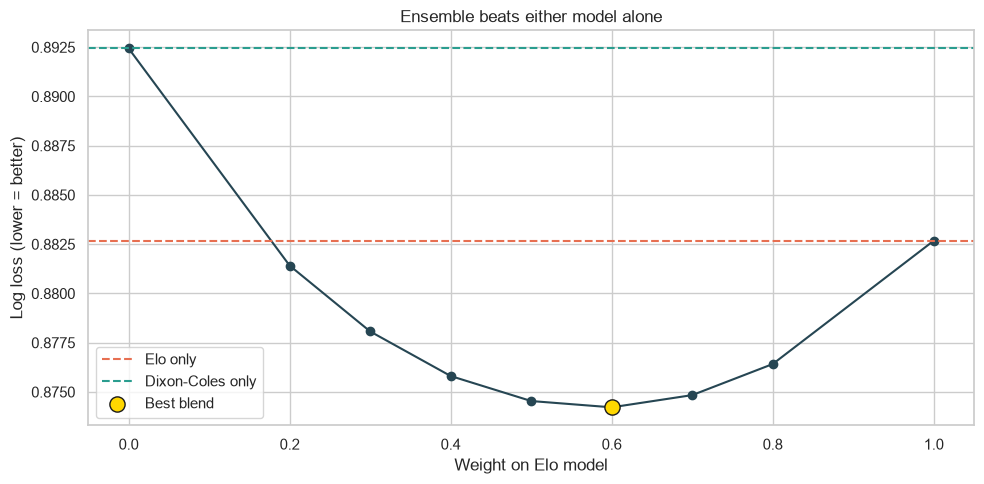

In [13]:
plt.plot(blend_tbl["Elo weight"], blend_tbl["Log loss"], marker="o", color="#264653")
plt.axhline(blend_tbl["Log loss"].iloc[-1], ls="--", color="#e76f51", label="Elo only")
plt.axhline(blend_tbl["Log loss"].iloc[0],  ls="--", color="#2a9d8f", label="Dixon-Coles only")
plt.scatter([best_w], [blend_tbl["Log loss"].min()], s=120, color="gold", zorder=5, edgecolor="k", label="Best blend")
plt.xlabel("Weight on Elo model"); plt.ylabel("Log loss (lower = better)")
plt.title("Ensemble beats either model alone"); plt.legend(); plt.tight_layout(); plt.show()

**Result:** the blend beats both components. Neither model is individually best — the
ensemble is. This is the forecaster we'll carry into the tournament simulation: a weighted
average of an Elo ratings model and a Dixon–Coles goals model.

> Honest takeaway for your README: the sophisticated model didn't win on its own, and that's
> fine — the point of benchmarking is to *find that out* rather than assume. The ensemble,
> grounded in two different views of the game, is both more accurate and better calibrated on
> draws than the simple baseline.

## 9. Save the fitted model
Phase 4's tournament simulation will load these strengths to rate the 2026 teams and play
out the bracket. We also record the winning blend weight.

In [14]:
import os, json
os.makedirs("../models", exist_ok=True)
dc_params = {
    "attack":  {t: float(atk[team_idx[t]]) for t in teams},
    "defense": {t: float(dfn[team_idx[t]]) for t in teams},
    "gamma": float(gamma),
    "rho": float(rho),
    "blend_elo_weight": float(best_w),   # chosen ensemble weight on the Elo model
}
with open("../models/dixon_coles.json", "w") as f:
    json.dump(dc_params, f, indent=2)
print("Saved ../models/dixon_coles.json with", len(teams), "teams and blend weight", best_w)

Saved ../models/dixon_coles.json with 216 teams and blend weight 0.6


---
### What's next (Phase 4)
We now have an ensemble forecaster that beats both baselines. Phase 4 builds the
**Monte Carlo simulator**. First it **refits the models on all data through June 2026** (so
the ratings reflect current form, not 2017), then it takes the real 2026 group draw,
simulates the entire tournament thousands of times using the blended match probabilities, and
tallies how often each team wins the cup. That produces the headline output —
*"Team X: 14% to win the World Cup"* — and the live bracket for your dashboard.